# P&P Trajectory Analysis — LIBERO-PRO

---
GPU Check & Drive Setup
Run every session.

In [ ]:
import subprocess, torch
print(subprocess.run(
    ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
    capture_output=True, text=True).stdout.strip())
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU:  {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

from google.colab import drive
import os
drive.mount('/content/drive')

DRIVE      = '/content/drive/MyDrive'
CACHE_DIR  = f'{DRIVE}/cs159_jeff/smolvla_colab_cache'
RESULTS_DIR = f'{DRIVE}/cs159_jeff/libero_pro_results'
DB_PATH    = f'{RESULTS_DIR}/rollouts_jeff_2_multimodal.db'
HF_HOME = f'{CACHE_DIR}/hf_models'
# SNAPSHOT   = f'{CACHE_DIR}/site_packages.tar.gz'
# LIBERO_TAR = f'{CACHE_DIR}/libero_pro_files.tar.gz'

os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(HF_HOME, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

os.environ['HF_HOME']               = HF_HOME
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['MUJOCO_GL']             = 'egl'

SNAPSHOT  = f'{CACHE_DIR}/site_packages.tar.gz'
PRO_CACHE = f'{CACHE_DIR}/libero_pro_files.tar.gz'

print(f'\nPackage snapshot: {"FOUND" if os.path.exists(SNAPSHOT) else "NOT FOUND — run Section 3"}')
print(f'LIBERO-PRO cache: {"FOUND" if os.path.exists(PRO_CACHE) else "NOT FOUND — run Section 5b"}')

NVIDIA L4, 23034 MiB
CUDA: True
GPU:  NVIDIA L4
VRAM: 23.7 GB
Mounted at /content/drive

Package snapshot: FOUND
LIBERO-PRO cache: FOUND


---
# A: Uncertainty and Success Rate Data

## A1. Load & Summarise Database

In [ ]:
import sqlite3, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.stats import pointbiserialr
from sklearn.metrics import roc_curve, auc

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# Connect (works whether we are continuing this session or loading a saved DB)
RESULTS_DIR = '/content/drive/MyDrive/cs159_jeff/libero_pro_results'
DB_PATH     = f'{RESULTS_DIR}/rollouts_jeff_2_0.db'
con_a       = sqlite3.connect(DB_PATH)
con_a.row_factory = sqlite3.Row

rollouts = pd.read_sql('SELECT * FROM rollouts', con_a)
steps_df = pd.read_sql('SELECT * FROM pnp_euler_steps', con_a)

# Parse JSON step indices
def _parse_idx(s):
    try:    return json.loads(s)
    except: return s
rollouts['step_indices_parsed'] = rollouts['pnp_step_indices'].map(_parse_idx)

# Phase splits
baseline = rollouts[rollouts.pnp_enabled == 0].copy()
pnp_all  = rollouts[rollouts.pnp_enabled == 1].copy()
phase2   = pnp_all[pnp_all['pnp_mode'] == 'uncertainty'].copy()
phase3   = pnp_all[pnp_all['pnp_mode'] == 'both'].copy()

steps_p2 = steps_df[steps_df['rollout_id'].isin(set(phase2['rollout_id']))].copy()
steps_p3 = steps_df[steps_df['rollout_id'].isin(set(phase3['rollout_id']))].copy()

# Suite type annotation
def suite_type(s):
    if 'temp_' in s:  return 'position_perturb'
    if '_with_' in s: return 'distractor'
    return 'other'
for df in [rollouts, baseline, pnp_all, phase2, phase3]:
    df['suite_type'] = df['suite'].map(suite_type)

print(f'Total rollouts: {len(rollouts)}')
print(f'  Baseline (phase 1): {len(baseline)}')
print(f'  Uncertainty only (phase 2): {len(phase2)}')
print(f'  Refinement (phase 3): {len(phase3)}')
print(f'  Euler steps rows: {len(steps_df)}')
print()
print('Suites in DB:', sorted(rollouts.suite.unique().tolist()))
print()
print('Baseline SR per suite:')
for suite, grp in baseline.groupby('suite'):
    print(f'  {suite:<45} {grp.success.mean():.1%}  (n={len(grp)})')

Total rollouts: 1800
  Baseline (phase 1): 600
  Uncertainty only (phase 2): 600
  Refinement (phase 3): 600
  Euler steps rows: 10964

Suites in DB: ['libero_goal_with_yellow_book', 'libero_object_temp_x0.1', 'libero_object_temp_x0.2', 'libero_object_temp_y0.1', 'libero_object_temp_y0.2', 'libero_spatial_with_milk']

Baseline SR per suite:
  libero_goal_with_yellow_book                  93.0%  (n=100)
  libero_object_temp_x0.1                       45.0%  (n=100)
  libero_object_temp_x0.2                       4.0%  (n=100)
  libero_object_temp_y0.1                       48.0%  (n=100)
  libero_object_temp_y0.2                       24.0%  (n=100)
  libero_spatial_with_milk                      81.0%  (n=100)


## A2. Phase Comparison — Uncertainty vs. Refinement

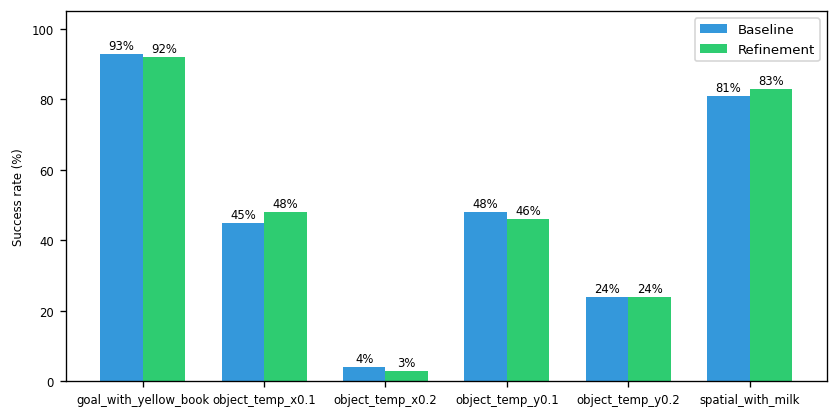

Aggregate SR over all episodes:
  baseline (n=600):           49.17%
  uncertainty only (n=600):     49.17%  (Δ +0.00 pp vs baseline)
  refinement (n=600):           49.33%  (Δ +0.17 pp vs baseline)


In [ ]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42   # TrueType, not Type-3 (RSS requirement)
matplotlib.rcParams['ps.fonttype'] = 42

matplotlib.rcParams.update({
    'font.size':        7,    # base — affects tick labels
    'axes.labelsize':   7,    # x/y axis labels
    'xtick.labelsize':  7,    # x tick labels
    'ytick.labelsize':  7,    # y tick labels
    'legend.fontsize':  70,    # legend only — bigger than the rest
})

if len(phase2) == 0 and len(phase3) == 0:
    print('No P&P data yet — run phases 2 and 3 first.')
else:
    suites = sorted(set(
        baseline['suite'].tolist() + phase2['suite'].tolist() + phase3['suite'].tolist()
    ))
    x  = np.arange(len(suites))
    w  = 0.35
    sr_base = baseline.groupby('suite')['success'].mean().reindex(suites).fillna(0)
    sr_p2   = phase2.groupby('suite')['success'].mean().reindex(suites).fillna(0)
    sr_p3   = phase3.groupby('suite')['success'].mean().reindex(suites).fillna(0)

    fig, ax = plt.subplots(figsize=(7, 3.5))
    b2 = ax.bar(x - w/2, sr_p2 * 100, width=w, label='Baseline', color='#3498db')
    b3 = ax.bar(x + w/2, sr_p3 * 100, width=w, label='Refinement',       color='#2ecc71')
    ax.set_xticks(x)
    ax.set_xticklabels([s.replace('libero_','') for s in suites], rotation=0, ha='center')
    ax.set_ylabel('Success rate (%)')
    ax.set_ylim(0, 105)
    ax.legend(fontsize=8)
    for bars_patch, vals in [(b2, sr_p2), (b3, sr_p3)]:
        for bar, v in zip(bars_patch, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{v*100:.0f}%', ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/phase_comparison.png', dpi=150)
    plt.show()

    # ── aggregate success-rate change across all episodes ──
    base_sr = baseline['success'].mean()
    p2_sr   = phase2['success'].mean()
    p3_sr   = phase3['success'].mean()
    print(f'Aggregate SR over all episodes:')
    print(f'  baseline (n={len(baseline)}):           {base_sr*100:.2f}%')
    print(f'  uncertainty only (n={len(phase2)}):     {p2_sr*100:.2f}%  '
          f'(Δ {(p2_sr-base_sr)*100:+.2f} pp vs baseline)')
    print(f'  refinement (n={len(phase3)}):           {p3_sr*100:.2f}%  '
          f'(Δ {(p3_sr-base_sr)*100:+.2f} pp vs baseline)')

## A3. Paired Episode Transition Analysis
For each episode, compares baseline outcome to P&P outcome (same `init_state_hash`).

Paired episodes: 600

Overall transition counts:
transition
failure → failure       252
success → success       243
failure → success  ✓     53
success → failure  ✗     52

Baseline SR:   49.2%
Refinement SR: 49.3%

Per-suite transitions:
  libero_goal_with_yellow_book               base=93%  pnp=92%  F→S=4  S→F=5
  libero_object_temp_x0.1                    base=45%  pnp=48%  F→S=13  S→F=10
  libero_object_temp_x0.2                    base=4%  pnp=3%  F→S=1  S→F=2
  libero_object_temp_y0.1                    base=48%  pnp=46%  F→S=15  S→F=17
  libero_object_temp_y0.2                    base=24%  pnp=24%  F→S=9  S→F=9
  libero_spatial_with_milk                   base=81%  pnp=83%  F→S=11  S→F=9


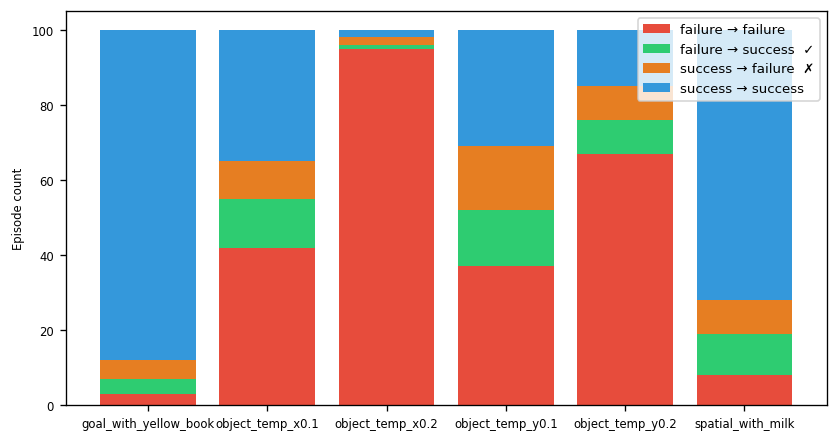

In [ ]:
matplotlib.rcParams['pdf.fonttype'] = 42   # TrueType, not Type-3 (RSS requirement)
matplotlib.rcParams['ps.fonttype'] = 42

matplotlib.rcParams.update({
    'font.size':        7,    # base — affects tick labels
    'axes.labelsize':   7,    # x/y axis labels
    'xtick.labelsize':  7,    # x tick labels
    'ytick.labelsize':  7,    # y tick labels
    'legend.fontsize':  60,    # legend only — bigger than the rest
})

ax.legend(
    fontsize=9,
    borderpad=1.0,
    labelspacing=0.6,
    handletextpad=0.6,
    handlelength=2.5,
    handleheight=1.2,
    framealpha=0.9,    # slightly transparent background
    edgecolor='gray',  # subtle border
)

if len(phase3) == 0:
    print('No Phase 3 data yet.')
else:
    # Pair baseline ↔ phase3 on (suite, task_idx, episode_idx, init_state_hash)
    b_key = baseline[['suite','task_idx','episode_idx','init_state_hash','success']].copy()
    b_key = b_key.rename(columns={'success': 'success_baseline'})
    p_key = phase3[['suite','task_idx','episode_idx','init_state_hash','success','u_mean_episode']].copy()
    p_key = p_key.rename(columns={'success': 'success_pnp'})

    paired = b_key.merge(p_key, on=['suite','task_idx','episode_idx','init_state_hash'], how='inner')
    print(f'Paired episodes: {len(paired)}')

    def _transition(row):
        b, p = int(row['success_baseline']), int(row['success_pnp'])
        if b == 1 and p == 1: return 'success → success'
        if b == 0 and p == 1: return 'failure → success  ✓'
        if b == 1 and p == 0: return 'success → failure  ✗'
        return 'failure → failure'

    paired['transition'] = paired.apply(_transition, axis=1)

    # Global counts
    counts = paired['transition'].value_counts()
    print('\nOverall transition counts:')
    print(counts.to_string())
    print(f'\nBaseline SR:   {paired.success_baseline.mean():.1%}')
    print(f'Refinement SR: {paired.success_pnp.mean():.1%}')

    # Per-suite table
    print('\nPer-suite transitions:')
    for suite, grp in paired.groupby('suite'):
        tc = grp['transition'].value_counts()
        f2s = tc.get('failure → success  ✓', 0)
        s2f = tc.get('success → failure  ✗', 0)
        print(f'  {suite:<42} '
              f'base={grp.success_baseline.mean():.0%}  '
              f'pnp={grp.success_pnp.mean():.0%}  '
              f'F→S={f2s}  S→F={s2f}')

    # Transition chart per suite
    suites = sorted(paired['suite'].unique())
    cats   = ['failure → failure', 'failure → success  ✓',
              'success → failure  ✗', 'success → success']
    cat_colors = ['#e74c3c', '#2ecc71', '#e67e22', '#3498db']

    fig, ax = plt.subplots(figsize=(7, 3.7))
    bottom = np.zeros(len(suites))
    for cat, color in zip(cats, cat_colors):
        vals = [
            paired[paired.suite == s]['transition'].value_counts().get(cat, 0)
            for s in suites
        ]
        ax.bar(range(len(suites)), vals, bottom=bottom, label=cat, color=color)
        bottom += np.array(vals, dtype=float)
    ax.set_xticks(range(len(suites)))
    ax.set_xticklabels([s.replace('libero_','') for s in suites], rotation=0, ha='center')
    ax.set_ylabel('Episode count')
    # ax.set_title('Baseline → Refinement outcome transitions per suite')
    ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/transition_chart.png', dpi=150)
    plt.show()

## A4. Threshold Window Sweep

Total paired episodes: 600
Overall baseline SR:   0.492


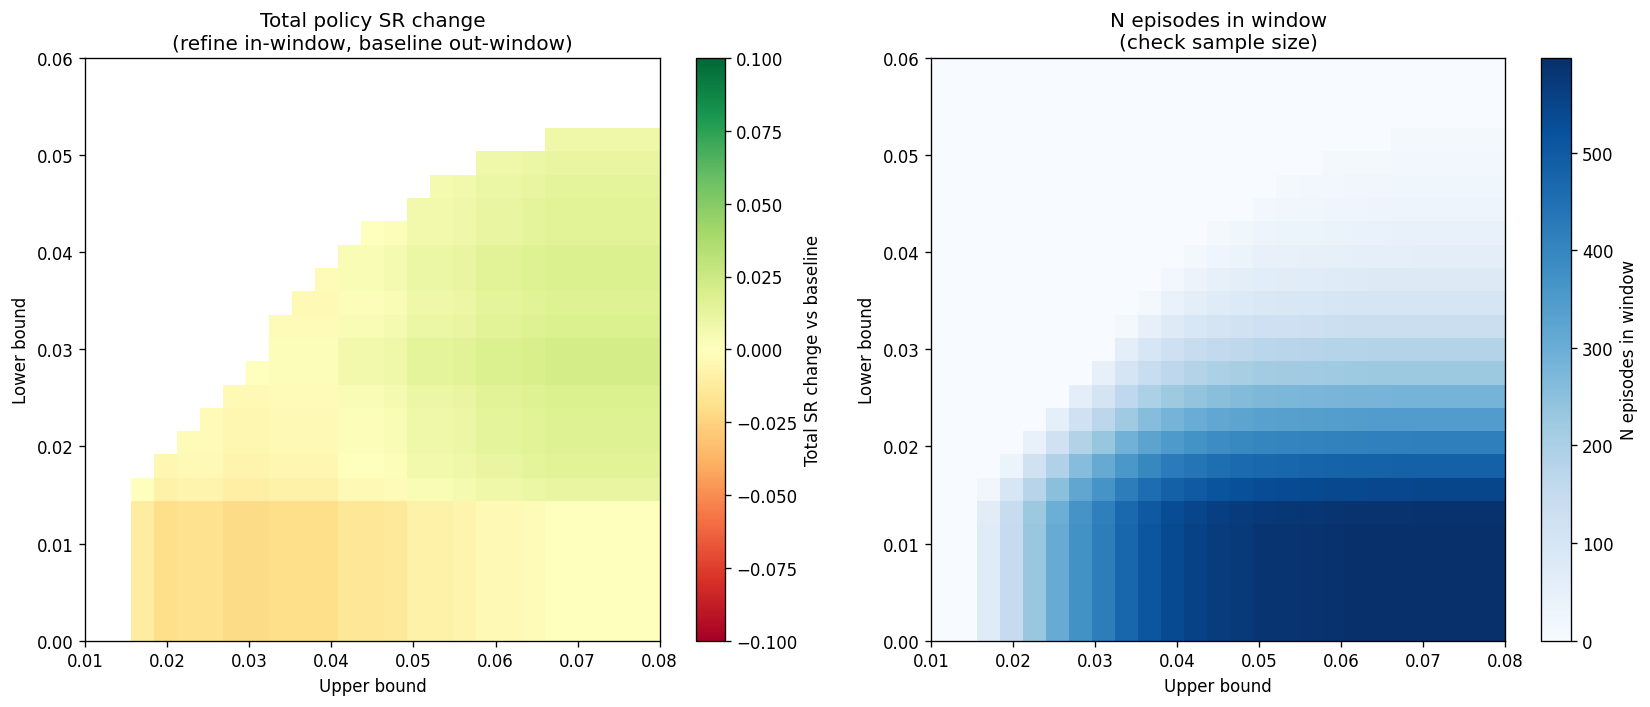


Overall baseline SR: 0.492

TOP 10 windows by TOTAL POLICY SR change:
   Lower    Upper      N  Tot SR chg  Base SR   Ref SR
-------------------------------------------------------
   0.028    0.068    225      +0.022    0.276    0.333
   0.028    0.071    226      +0.022    0.274    0.332
   0.028    0.074    226      +0.022    0.274    0.332
   0.028    0.077    226      +0.022    0.274    0.332
   0.028    0.080    226      +0.022    0.274    0.332
   0.030    0.068    183      +0.022    0.251    0.322
   0.030    0.071    184      +0.022    0.250    0.321
   0.030    0.074    184      +0.022    0.250    0.321
   0.030    0.077    184      +0.022    0.250    0.321
   0.030    0.080    184      +0.022    0.250    0.321

BOTTOM 10 windows by TOTAL POLICY SR change (most degradation):
   Lower    Upper      N  Tot SR chg  Base SR   Ref SR
-------------------------------------------------------
   0.000    0.028    371      -0.022    0.628    0.593
   0.000    0.030    419      -0.022 

In [ ]:
import sqlite3, numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype']  = 42

DB_PATH_JEFF = '/content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_jeff_2_0.db'
con = sqlite3.connect(DB_PATH_JEFF)
df = pd.read_sql('SELECT * FROM rollouts', con)
con.close()

# Pair phases
base = df[df.pnp_enabled==0][['suite','task_idx','episode_idx','init_state_hash','success']]\
         .rename(columns={'success':'base_success'})
unc  = df[(df.pnp_enabled==1)&(df.pnp_mode=='uncertainty')]\
         [['suite','task_idx','episode_idx','init_state_hash','success','u_mean_episode']]\
         .rename(columns={'success':'unc_success'})
ref  = df[(df.pnp_enabled==1)&(df.pnp_mode=='both')]\
         [['suite','task_idx','episode_idx','init_state_hash','success']]\
         .rename(columns={'success':'ref_success'})

paired = base.merge(unc, on=['suite','task_idx','episode_idx','init_state_hash'], how='inner')\
             .merge(ref, on=['suite','task_idx','episode_idx','init_state_hash'], how='inner')

total_n        = len(paired)
overall_base_sr = paired.base_success.mean()
print(f'Total paired episodes: {total_n}')
print(f'Overall baseline SR:   {overall_base_sr:.3f}')

# ── Sweep ─────────────────────────────────────────────────────────────────────
lower_bounds = np.linspace(0.0,  0.06, 25)
upper_bounds = np.linspace(0.01, 0.08, 25)

sr_change_total = np.full((len(lower_bounds), len(upper_bounds)), np.nan)
n_episodes      = np.zeros((len(lower_bounds), len(upper_bounds)))

for i, lo in enumerate(lower_bounds):
    for j, hi in enumerate(upper_bounds):
        if hi <= lo:
            continue
        in_window  = paired[(paired.u_mean_episode >= lo) & (paired.u_mean_episode <= hi)]
        out_window = paired[(paired.u_mean_episode <  lo) | (paired.u_mean_episode >  hi)]
        if len(in_window) < 10:
            continue
        n_episodes[i, j] = len(in_window)
        successes_in  = in_window.ref_success.sum()
        successes_out = out_window.base_success.sum()
        sr_change_total[i, j] = (successes_in + successes_out) / total_n - overall_base_sr

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im1 = axes[0].imshow(sr_change_total, aspect='auto', origin='lower',
                     cmap='RdYlGn', vmin=-0.1, vmax=0.1,
                     extent=[upper_bounds[0], upper_bounds[-1],
                              lower_bounds[0], lower_bounds[-1]])
plt.colorbar(im1, ax=axes[0], label='Total SR change vs baseline')
axes[0].set_xlabel('Upper bound')
axes[0].set_ylabel('Lower bound')
axes[0].set_title('Total policy SR change\n(refine in-window, baseline out-window)')

im2 = axes[1].imshow(n_episodes, aspect='auto', origin='lower',
                     cmap='Blues',
                     extent=[upper_bounds[0], upper_bounds[-1],
                              lower_bounds[0], lower_bounds[-1]])
plt.colorbar(im2, ax=axes[1], label='N episodes in window')
axes[1].set_xlabel('Upper bound')
axes[1].set_ylabel('Lower bound')
axes[1].set_title('N episodes in window\n(check sample size)')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cs159_jeff/libero_pro_results/threshold_2d_heatmap_v2.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Top/bottom windows ────────────────────────────────────────────────────────
results = []
for i, lo in enumerate(lower_bounds):
    for j, hi in enumerate(upper_bounds):
        if np.isnan(sr_change_total[i, j]) or n_episodes[i, j] < 20:
            continue
        in_window  = paired[(paired.u_mean_episode >= lo) & (paired.u_mean_episode <= hi)]
        out_window = paired[(paired.u_mean_episode <  lo) | (paired.u_mean_episode >  hi)]
        successes_in  = in_window.ref_success.sum()
        successes_out = out_window.base_success.sum()
        total_sr_policy = (successes_in + successes_out) / total_n
        results.append({
            'lo': lo, 'hi': hi, 'n': len(in_window),
            'total_sr_change': total_sr_policy - overall_base_sr,
            'base_sr_window':  in_window.base_success.mean(),
            'ref_sr_window':   in_window.ref_success.mean(),
            'total_sr_policy': total_sr_policy,
        })

results_df = pd.DataFrame(results)

hdr = f'{"Lower":>8} {"Upper":>8} {"N":>6} {"Tot SR chg":>11} {"Base SR":>8} {"Ref SR":>8}'
sep = '-' * 55

print(f'\nOverall baseline SR: {overall_base_sr:.3f}')

print(f'\n{"==="*20}')
print('TOP 10 windows by TOTAL POLICY SR change:')
print(hdr); print(sep)
for _, r in results_df.nlargest(10, 'total_sr_change').iterrows():
    print(f'{r.lo:>8.3f} {r.hi:>8.3f} {r.n:>6.0f} '
          f'{r.total_sr_change:>+11.3f} {r.base_sr_window:>8.3f} {r.ref_sr_window:>8.3f}')

print(f'\n{"==="*20}')
print('BOTTOM 10 windows by TOTAL POLICY SR change (most degradation):')
print(hdr); print(sep)
for _, r in results_df.nsmallest(10, 'total_sr_change').iterrows():
    print(f'{r.lo:>8.3f} {r.hi:>8.3f} {r.n:>6.0f} '
          f'{r.total_sr_change:>+11.3f} {r.base_sr_window:>8.3f} {r.ref_sr_window:>8.3f}')

## A5. ROC / AUC — Uncertainty as Failure Predictor

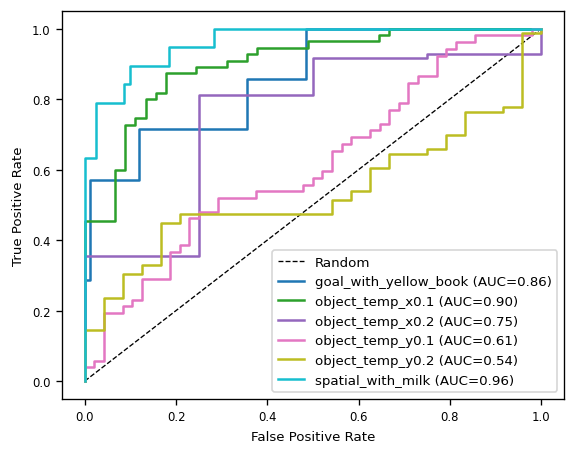


AUC by suite:
  libero_spatial_with_milk                      AUC=0.962  [distractor]
  libero_object_temp_x0.1                       AUC=0.901  [pos_perturb]
  libero_goal_with_yellow_book                  AUC=0.860  [distractor]
  libero_object_temp_x0.2                       AUC=0.753  [pos_perturb]
  libero_object_temp_y0.1                       AUC=0.613  [pos_perturb]
  libero_object_temp_y0.2                       AUC=0.535  [pos_perturb]

Mean AUC across suites: 0.771


In [ ]:
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype']  = 42

matplotlib.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype':  42,
    'font.size':    80,        # base font size
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
})

if len(phase2) == 0:
    print('No Phase 2 data yet.')
else:
    sub = phase2.dropna(subset=['u_mean_episode'])
    suites = sorted(sub['suite'].unique())

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0,1],[0,1],'k--',lw=0.8, label='Random')

    auc_results = {}
    colors_suite = plt.cm.tab10(np.linspace(0, 1, len(suites)))

    for suite, color in zip(suites, colors_suite):
        g = sub[sub.suite == suite]
        if g['success'].nunique() < 2:
            print(f'  Skipping {suite}: only one outcome class present')
            continue
        # Higher uncertainty → predicts failure (success=0)
        fpr, tpr, _ = roc_curve(1 - g['success'], g['u_mean_episode'])
        roc_auc = auc(fpr, tpr)
        auc_results[suite] = roc_auc
        ax.plot(fpr, tpr, color=color, lw=1.5,
                label=f'{suite.replace("libero_","")} (AUC={roc_auc:.2f})')

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    # ax.set_title('ROC: uncertainty as failure predictor (Phase 2)')
    ax.legend(fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/roc_curves.png', dpi=150)
    plt.show()

    print('\nAUC by suite:')
    for suite, a_val in sorted(auc_results.items(), key=lambda x: -x[1]):
        stype = 'pos_perturb' if 'temp_' in suite else 'distractor'
        print(f'  {suite:<45} AUC={a_val:.3f}  [{stype}]')

    if auc_results:
        overall_auc = np.mean(list(auc_results.values()))
        print(f'\nMean AUC across suites: {overall_auc:.3f}')

## B: Geometric Analysis

In [ ]:
DB_PATH = f'{RESULTS_DIR}/rollouts_jeff_2_multimodal.db'
import sqlite3
con = sqlite3.connect(DB_PATH)   # reopen — a prior cell had closed it

real_before  = con.execute("SELECT COUNT(*) FROM rollouts WHERE rollout_id NOT LIKE 'synthbase_%'").fetchone()[0]
synth_before = con.execute("SELECT COUNT(*) FROM rollouts WHERE rollout_id LIKE 'synthbase_%'").fetchone()[0]
print(f'before: {real_before} real rollouts, {synth_before} synthetic')

con.execute("DELETE FROM rollouts WHERE rollout_id LIKE 'synthbase_%'")   # only ever removes prior synthbase rows
con.execute("""
INSERT INTO rollouts (rollout_id, suite, task_idx, episode_idx, init_state_hash,
    success, n_steps, elapsed_s, pnp_enabled, timestamp)
SELECT 'synthbase_'||rollout_id, suite, task_idx, episode_idx, init_state_hash,
    success, n_steps, elapsed_s, 0, timestamp
FROM rollouts WHERE pnp_enabled=1 AND pnp_mode='uncertainty'
""")
con.commit()

real_after  = con.execute("SELECT COUNT(*) FROM rollouts WHERE rollout_id NOT LIKE 'synthbase_%'").fetchone()[0]
synth_after = con.execute("SELECT COUNT(*) FROM rollouts WHERE rollout_id LIKE 'synthbase_%'").fetchone()[0]
print(f'after : {real_after} real rollouts, {synth_after} synthetic')
assert real_after == real_before, 'real rollouts changed — STOP and investigate'
print('Real results untouched ✓')

before: 1200 real rollouts, 600 synthetic
after : 1200 real rollouts, 600 synthetic
Real results untouched ✓


In [ ]:
import sqlite3, json, numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score

c = sqlite3.connect(DB_PATH)
roll  = pd.read_sql("SELECT * FROM rollouts WHERE pnp_enabled=1 AND pnp_mode='uncertainty'", c)
steps = pd.read_sql("SELECT rollout_id, chunk_idx, u_mean FROM pnp_euler_steps", c)
vec   = pd.read_sql("SELECT rollout_id, a_std_vec FROM pnp_action_vectors", c)
try:
    msb = pd.read_sql("SELECT init_state_hash, ms_pair_l2 FROM baseline_uncertainty", c)
except Exception:
    msb = pd.DataFrame(columns=['init_state_hash','ms_pair_l2'])
c.close()

u0 = (steps[steps.chunk_idx == 0].groupby('rollout_id')['u_mean'].mean()
      .reset_index().rename(columns={'u_mean':'u_first_chunk'}))
def _astd(s):
    vals = [np.mean(json.loads(x)) for x in s if x and x != '[]']
    return float(np.mean(vals)) if vals else np.nan
astd = (vec.groupby('rollout_id')['a_std_vec'].apply(_astd)
        .reset_index().rename(columns={'a_std_vec':'a_std'}))

df = roll.merge(u0, on='rollout_id', how='left').merge(astd, on='rollout_id', how='left')
if not msb.empty:
    ms = (msb.groupby('init_state_hash')['ms_pair_l2'].mean()
          .reset_index().rename(columns={'ms_pair_l2':'ms'}))
    df = df.merge(ms, on='init_state_hash', how='left')
else:
    df['ms'] = np.nan

MEASURES = [('u_mean_episode','P&P u_mean (episode)'), ('u_first_chunk','P&P u (chunk 0)'),
            ('a_std','P&P a_std (free)'), ('mm_bc_pc1_episode','PC1 bimodality'),
            ('ms','multi-sample var (chunk 0)')]
suites = sorted(df['suite'].dropna().unique())
rows = []
for col, label in MEASURES:
    if col not in df.columns: continue
    per = {}
    for su in suites:
        s = df[df.suite == su].dropna(subset=[col, 'success'])
        if s['success'].nunique() < 2 or len(s) < 10: per[su] = np.nan; continue
        try: per[su] = roc_auc_score(1 - s['success'], s[col])
        except Exception: per[su] = np.nan
    rows.append({'measure': label,
                 **{su.replace('libero_','').replace('object_',''):
                    (round(per[su],3) if per[su]==per[su] else np.nan) for su in suites},
                 'mean': round(np.nanmean(list(per.values())),3)})
print(pd.DataFrame(rows).to_string(index=False))
print('\nWithin-suite AUC (failure prediction). Compare ms vs P&P u (chunk 0): same probe point.')
print('Per-suite columns + their mean are the honest numbers — never pool episodes across suites.')


                   measure  goal_with_yellow_book  temp_x0.1  temp_x0.2  temp_y0.1  temp_y0.2  spatial_with_milk  mean
      P&P u_mean (episode)                  0.772      0.919      0.820      0.621      0.530              0.949 0.769
           P&P u (chunk 0)                  0.442      0.542      0.440      0.534      0.492              0.717 0.528
          P&P a_std (free)                  0.776      0.914      0.812      0.622      0.525              0.960 0.768
            PC1 bimodality                  0.613      0.522      0.484      0.397      0.493              0.533 0.507
multi-sample var (chunk 0)                    NaN        NaN        NaN        NaN        NaN                NaN   NaN

Within-suite AUC (failure prediction). Compare ms vs P&P u (chunk 0): same probe point.
Per-suite columns + their mean are the honest numbers — never pool episodes across suites.


/tmp/ipykernel_694/815219915.py:46: RuntimeWarning: Mean of empty slice
  'mean': round(np.nanmean(list(per.values())),3)})


## Multimodality decomposition — does bimodality explain high-U successes?

Among high-U episodes, test whether PC1 bimodality predicts *success* (multimodal = several valid plans) vs failure (diffuse/unstable). If `BC|succ > BC|fail` and AUC > ~0.6, multimodality explains the high-U-success false positives that cap F1.

In [ ]:
import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score

d = df.dropna(subset=['u_mean_episode','mm_bc_pc1_episode','success']).copy()
print(f'{"suite":<26}{"n_highU":>8}{"n_S":>6}{"n_F":>6}{"BC|succ":>9}{"BC|fail":>9}{"AUC(BC->succ)":>15}')
print('-'*79)
aucs = []
for su in sorted(d['suite'].unique()):
    s = d[d.suite == su]; thr = s['u_mean_episode'].median()
    hi = s[s['u_mean_episode'] >= thr]
    if hi['success'].nunique() < 2 or len(hi) < 8:
        print(f'{su.replace("libero_","")[:26]:<26}{len(hi):>8}{"–":>6}{"–":>6}{"–":>9}{"–":>9}{"(too few)":>15}')
        continue
    bc_s = hi[hi.success==1]['mm_bc_pc1_episode'].mean()
    bc_f = hi[hi.success==0]['mm_bc_pc1_episode'].mean()
    n_s  = int((hi.success==1).sum())
    n_f  = int((hi.success==0).sum())
    auc  = roc_auc_score(hi['success'], hi['mm_bc_pc1_episode'])
    aucs.append(auc)
    print(f'{su.replace("libero_","")[:26]:<26}{len(hi):>8}{n_s:>6}{n_f:>6}'
          f'{bc_s:>9.3f}{bc_f:>9.3f}{auc:>15.3f}')
print('-'*79)
print(f'mean within-suite AUC(bimodality -> success | high-U): {np.nanmean(aucs):.3f}'
      if aucs else 'no suites with enough high-U episodes')
print('If BC|succ > BC|fail and AUC > ~0.6, multimodality explains the high-U successes.')

suite                      n_highU   n_S   n_F  BC|succ  BC|fail  AUC(BC->succ)
-------------------------------------------------------------------------------
goal_with_yellow_book           50    42     8    0.391    0.407          0.318
object_temp_x0.1                50     6    44    0.403    0.409          0.492
object_temp_x0.2                50     1    49    0.368    0.414          0.000
object_temp_y0.1                50    21    29    0.427    0.407          0.609
object_temp_y0.2                50    11    39    0.411    0.412          0.487
spatial_with_milk               50    27    23    0.394    0.404          0.424
-------------------------------------------------------------------------------
mean within-suite AUC(bimodality -> success | high-U): 0.388
If BC|succ > BC|fail and AUC > ~0.6, multimodality explains the high-U successes.


    dim  mean_auc  n_suites
      x  0.704006         6
      y  0.757117         6
      z  0.755962         6
   roll  0.727120         6
  pitch  0.707620         6
    yaw  0.765003         6
gripper  0.695029         6

all-dims (mean U) baseline AUC: 0.771
If every per-dim AUC ~= the all-dims baseline, no single dimension localizes the signal.


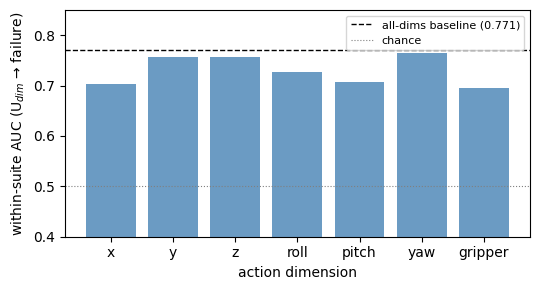

In [ ]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42   # TrueType, not Type-3
matplotlib.rcParams['ps.fonttype'] = 42

# ── Per-dimension uncertainty AUC: does any single action dim carry the failure signal? ──
import sqlite3, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

DB_PATH = f'{RESULTS_DIR}/rollouts_jeff_2_0.db'   # set to the verified-no-op DB
DIM_NAMES = ['x', 'y', 'z', 'roll', 'pitch', 'yaw', 'gripper']

c = sqlite3.connect(DB_PATH)
roll = pd.read_sql(
    "SELECT rollout_id, suite, success FROM rollouts "
    "WHERE pnp_enabled=1 AND pnp_mode='uncertainty'", c)
av = pd.read_sql(
    "SELECT rollout_id, u_vec FROM pnp_action_vectors", c)
c.close()

# parse the 7-d u_vec JSON, average over all (chunk, euler_step) rows per rollout
av = av.dropna(subset=['u_vec']).copy()
av['u_arr'] = av['u_vec'].apply(lambda s: np.asarray(json.loads(s), dtype=float))
av = av[av['u_arr'].apply(lambda a: a.shape == (7,))]
per_roll = (av.groupby('rollout_id')['u_arr']
            .apply(lambda g: np.mean(np.stack(g.values), axis=0)))
per_roll = per_roll.reset_index()
per_roll[DIM_NAMES] = pd.DataFrame(per_roll['u_arr'].tolist(), index=per_roll.index)

d = roll.merge(per_roll.drop(columns='u_arr'), on='rollout_id', how='inner')
d['fail'] = 1 - d['success']
suites = sorted(d['suite'].unique())

# within-suite AUC of each per-dim U -> failure, averaged across suites
rows = []
for dim in DIM_NAMES:
    per_suite = []
    for su in suites:
        s = d[d.suite == su].dropna(subset=[dim, 'fail'])
        if s['fail'].nunique() == 2 and len(s) >= 10:
            per_suite.append(roc_auc_score(s['fail'], s[dim]))
    rows.append({'dim': dim, 'mean_auc': np.nanmean(per_suite),
                 'n_suites': len(per_suite)})
res = pd.DataFrame(rows)

# also the all-dims (episode u_mean) baseline for reference
all_dim_auc = []
d['u_all'] = d[DIM_NAMES].mean(axis=1)
for su in suites:
    s = d[d.suite == su].dropna(subset=['u_all', 'fail'])
    if s['fail'].nunique() == 2 and len(s) >= 10:
        all_dim_auc.append(roc_auc_score(s['fail'], s['u_all']))
all_dim_auc = np.nanmean(all_dim_auc)

print(res.to_string(index=False))
print(f'\nall-dims (mean U) baseline AUC: {all_dim_auc:.3f}')
print('If every per-dim AUC ~= the all-dims baseline, no single dimension localizes the signal.')

# ── plot ──
fig, ax = plt.subplots(figsize=(5.5, 3))
ax.bar(res['dim'], res['mean_auc'], color='steelblue', alpha=0.8)
ax.axhline(all_dim_auc, color='black', linestyle='--', linewidth=1,
           label=f'all-dims baseline ({all_dim_auc:.3f})')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=0.8, label='chance')
ax.set_ylabel('within-suite AUC (U$_{dim}$ → failure)')
ax.set_xlabel('action dimension')
ax.set_ylim(0.4, max(0.85, res['mean_auc'].max() + 0.05))
# ax.set_title('Per-dimension uncertainty as failure predictor')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('per_dim_auc.pdf', bbox_inches='tight')
plt.show()

# First-Prediction PC1 Analysis

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import sqlite3, json, numpy as np
from sklearn.decomposition import PCA

pc1_succ, pc1_fail = [], []
rows = []

for key, succ, sj in sqlite3.connect(
        f'{RESULTS_DIR}/mm_cluster_samples_stratified.db').execute(
        "SELECT episode_key, success, samples_json FROM mm_samples"):
    X = np.array(json.loads(sj))
    Xs = (X - X.mean(0)) / (X.std(0) + 1e-9)
    evr = PCA().fit(Xs).explained_variance_ratio_
    (pc1_succ if succ else pc1_fail).append(float(evr[0]))
    rows.append((bool(succ), key, evr[0], evr[:3]))
    print(f"{'S' if succ else 'F'} {key[:38]:<38} "
          f"PC1 frac={evr[0]:.2f}  top3={evr[:3].round(2)}")

all_pc1 = pc1_succ + pc1_fail
print('\n' + '='*55)
print(f'n episodes:        {len(all_pc1)} ({len(pc1_succ)} S, {len(pc1_fail)} F)')
print(f'PC1 frac range:    {min(all_pc1):.3f} – {max(all_pc1):.3f}')
print(f'PC1 frac mean:     {np.mean(all_pc1):.3f}  (S {np.mean(pc1_succ):.3f}, F {np.mean(pc1_fail):.3f})')
print(f'N samples, D dims: {X.shape[0]}, {X.shape[1]}')
# Marchenko-Pastur upper edge for noise-only: (1 + sqrt(D/N))^2 / D  (as a variance-ratio scale)
N, D = X.shape
print(f'(for the paper: N={N}, D={D})')

# ready-to-paste list for the plotting cell
print('\npc1_data = [')
for succ, key, p, _ in rows:
    print(f"    ({'1' if succ else '0'}, {p:.4f}),  # {key[:40]}")
print(']')

S libero_goal_with_yellow_book|5|6       PC1 frac=0.08  top3=[0.08 0.06 0.06]
S libero_goal_with_yellow_book|0|1       PC1 frac=0.11  top3=[0.11 0.09 0.08]
S libero_goal_with_yellow_book|9|7       PC1 frac=0.11  top3=[0.11 0.08 0.08]
F libero_goal_with_yellow_book|3|5       PC1 frac=0.10  top3=[0.1  0.06 0.06]
F libero_goal_with_yellow_book|5|7       PC1 frac=0.11  top3=[0.11 0.06 0.05]
F libero_goal_with_yellow_book|2|3       PC1 frac=0.17  top3=[0.17 0.07 0.06]
S libero_object_temp_x0.1|3|7            PC1 frac=0.10  top3=[0.1  0.08 0.07]
S libero_object_temp_x0.1|3|2            PC1 frac=0.11  top3=[0.11 0.08 0.06]
S libero_object_temp_x0.1|0|1            PC1 frac=0.11  top3=[0.11 0.07 0.06]
F libero_object_temp_x0.1|9|9            PC1 frac=0.12  top3=[0.12 0.09 0.06]
F libero_object_temp_x0.1|0|5            PC1 frac=0.09  top3=[0.09 0.07 0.07]
F libero_object_temp_x0.1|6|1            PC1 frac=0.09  top3=[0.09 0.07 0.07]
S libero_object_temp_x0.2|4|6            PC1 frac=0.10  top3=[0.

Plot per-episode PC1 Frac Values

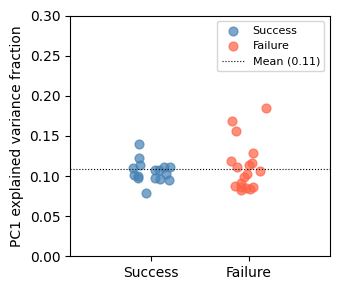

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['pdf.fonttype'] = 42   # TrueType, not Type-3
matplotlib.rcParams['ps.fonttype'] = 42

# uses `rows` from the PCA cell above: list of (success_bool, key, pc1_frac, top3)
succ = sorted(p for s, k, p, _ in rows if s)
fail = sorted(p for s, k, p, _ in rows if not s)
all_pc1 = succ + fail

fig, ax = plt.subplots(figsize=(3.5, 3))
jitter = 0.06
np.random.seed(42)
ax.scatter(np.random.uniform(-jitter, jitter, len(succ)),
           succ, color='steelblue', alpha=0.7, s=40, label='Success')
ax.scatter(0.3 + np.random.uniform(-jitter, jitter, len(fail)),
           fail, color='tomato', alpha=0.7, s=40, label='Failure')
ax.axhline(np.mean(all_pc1), color='black', linestyle=':', linewidth=0.8,
           label=f'Mean ({np.mean(all_pc1):.2f})')
ax.set_xticks([0, 0.3])
ax.set_xticklabels(['Success', 'Failure'])
ax.set_xlim(-0.25, 0.55)
ax.set_ylabel('PC1 explained variance fraction')
ax.set_ylim(0, 0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('pca_isotropy.pdf', bbox_inches='tight')
plt.show()